<a href="https://colab.research.google.com/github/skandanyal/ML-Lab-7th-sem/blob/main/mlLab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction

## Importing standard libraries and dataset

In [1]:
# mentioning all the imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
# importing the dataset

import kagglehub
import pandas as pd
import os

# Download latest version
# This returns the base directory where the dataset files are located
dataset_base_path = kagglehub.dataset_download("alsaniipe/heart-disease")

print("Path to dataset files:", dataset_base_path)

# The chosen file for the UCI Heart Disease (Cleveland) dataset
file_name = "processed.cleveland.data"
full_file_path = os.path.join(dataset_base_path, file_name)

# Define column names according to the UCI Heart Disease dataset attributes
# as hinted by the 'features' text cell (iy3qcMiMROq6).
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the dataset into a pandas DataFrame.
# The UCI .data files typically do not have a header and use '?' for missing values.
df = pd.read_csv(full_file_path, header=None, na_values='?', names=column_names)

100%|██████████| 139k/139k [00:00<00:00, 382kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alsaniipe/heart-disease/versions/1


In [4]:
features = '''
1. age
2. sex - gender
3. cp - chest pain type (4 values)
4. trestbpm - resting blood pressure (in mm Hg)
5. chol - serum cholestoral (in mg/dl)
6. fbs - fasting blood sugar > 120 mg/dl
7. restecg - resting electrocardiographic results (values 0,1,2)
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina
10. oldpeak - ST depression induced by exercise relative to rest
11. slope - the slope of the peak exercise ST segment
12. ca - number of major vessels (0-3) colored by flourosopy
13. thal - 0 = normal; 1 = fixed defect; 2 = reversable defect
14. target - sur
'''

## Data Cleaning

Removing any NaN values in the dataset.

In [5]:
# let us look at the features and their datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


There are no null values in the dataset - one less checkbox to worry about!

In [6]:
# let us look at the central tendencies of the features in the dataset

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
# segregating numerical and categorical data

df_num = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]                          # use histogram
df_cat = df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']]            # value count

In [9]:
df_num.head()

,age,trestbps,chol,thalach,oldpeak
0,63.0,145.0,233.0,150.0,2.3
1,67.0,160.0,286.0,108.0,1.5
2,67.0,120.0,229.0,129.0,2.6
3,37.0,130.0,250.0,187.0,3.5
4,41.0,130.0,204.0,172.0,1.4


In [10]:
df_cat.head()

,sex,cp,fbs,restecg,exang,slope,ca,thal
0,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0
1,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0
2,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0
3,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0
4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0


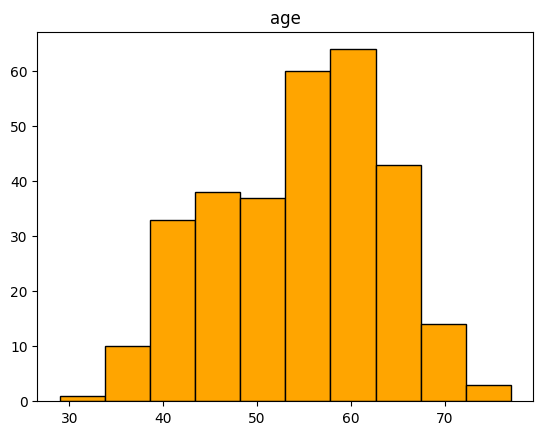

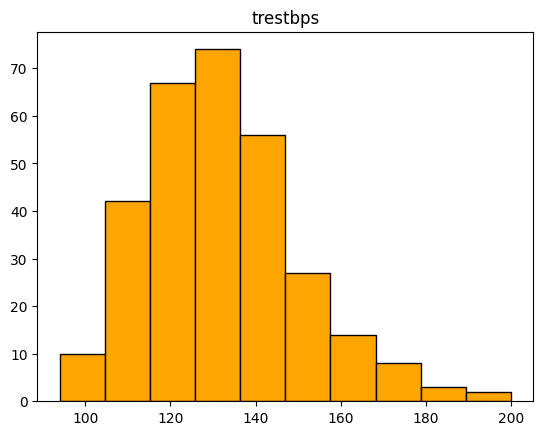

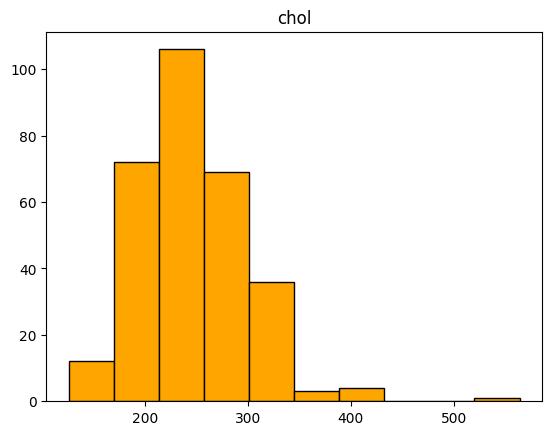

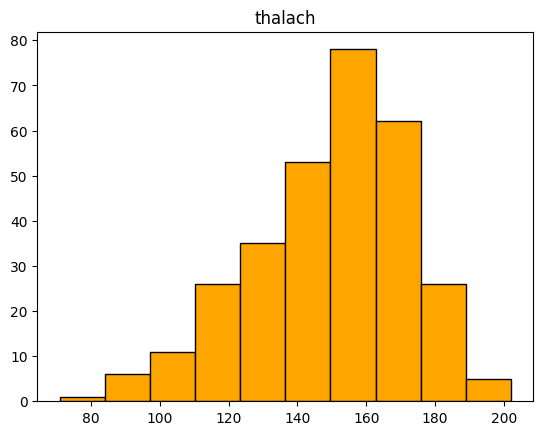

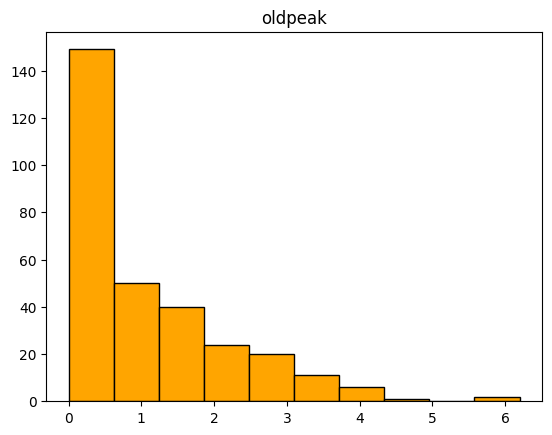

In [11]:
# histograms of all numerical values

for cat in df_num.columns:
    plt.hist(df_num[cat], color='orange', edgecolor='black', )
    plt.title(cat)
    plt.show()

We see that the `oldpeak` data does not resembe a normal data. Hence, transform it by applying lograthmic function.

In [12]:
# applying log function to oldpeak

df['log_oldpeak'] = np.log(df['oldpeak'] + 1)

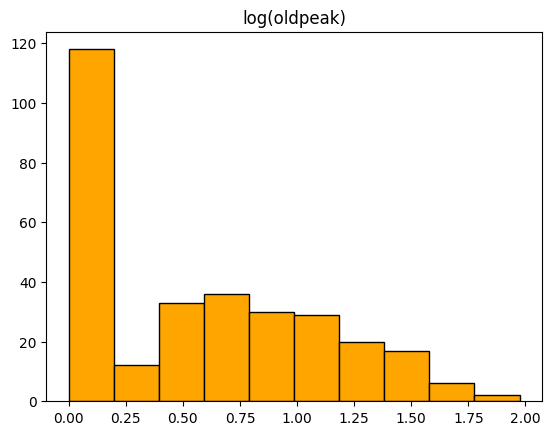

In [13]:
# let us look at the histogram of the transformed metric

plt.hist(df['log_oldpeak'], color='orange', edgecolor='black')
plt.title('log(oldpeak)')
plt.show()

The data still does not conform to a bell shape. Let us try a much stricter transformation like `Yeo-Jhonson`.

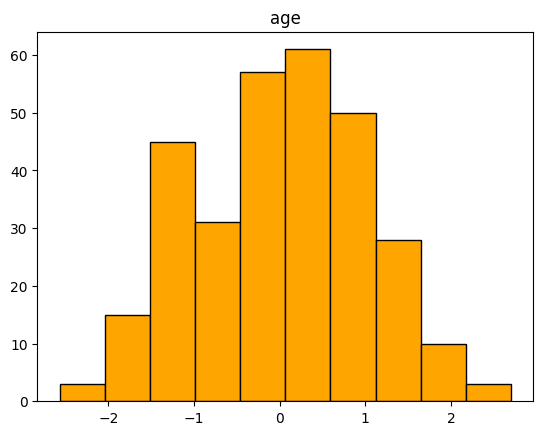

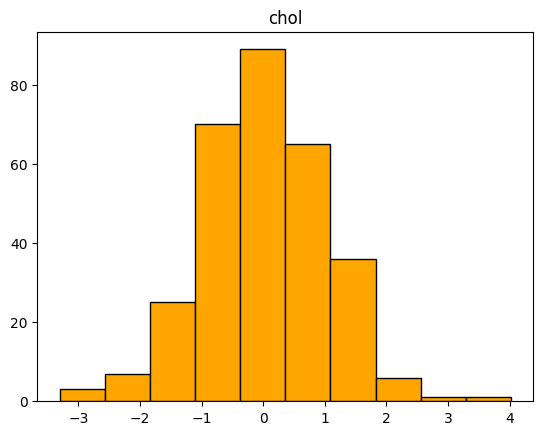

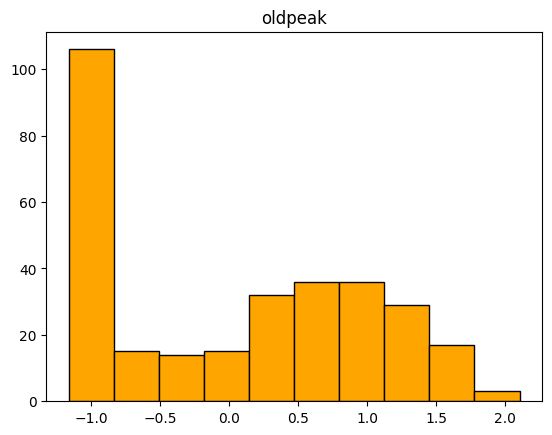

In [14]:
# let us also tranfsorm age and chol along with oldpeak

from sklearn.preprocessing import PowerTransformer

cols = ['age', 'chol', 'oldpeak']
pt = PowerTransformer(method='yeo-johnson')
df_transformed = pd.DataFrame(pt.fit_transform(df[cols]), columns=cols)

for cat in df_transformed.columns:
    plt.hist(df_transformed[cat], color='orange', edgecolor='black')
    plt.title(cat)
    plt.show()

The applied transformation still could not fix `oldpeak`. We shall now use that regardless.

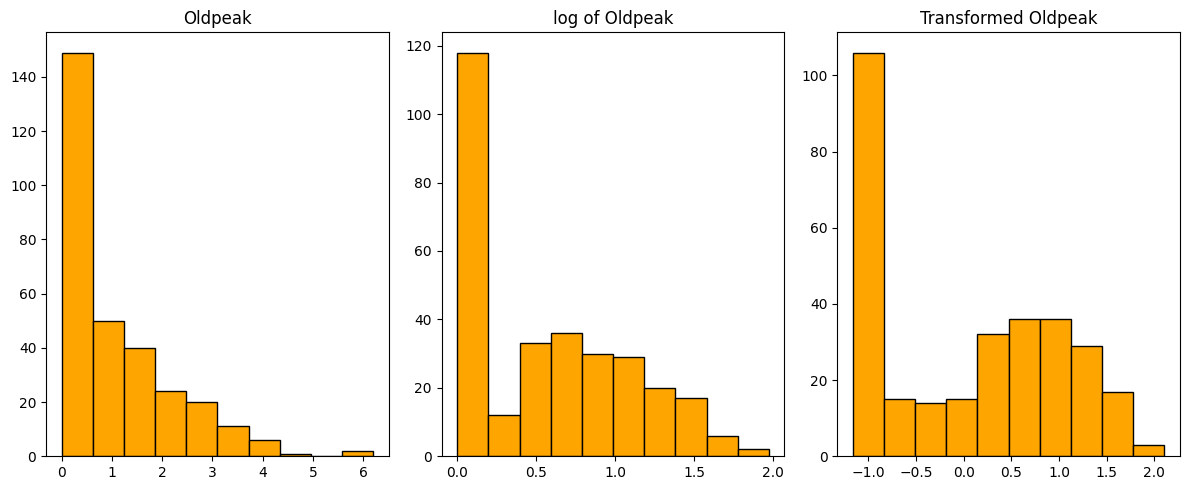

In [15]:
# comparing the original oldpeak, log_oldpeak and transformed oldpeak side by side

fix, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12,5))

ax1.hist(df['oldpeak'], color='orange', edgecolor='black')
ax1.set(title='Oldpeak')

ax2.hist(df['log_oldpeak'], color='orange', edgecolor='black')
ax2.set(title='log of Oldpeak')

ax3.hist(df_transformed['oldpeak'], color='orange', edgecolor='black')
ax3.set(title='Transformed Oldpeak')

plt.tight_layout()
plt.show()

               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.284946  0.208950 -0.393806  0.203805
trestbps  0.284946  1.000000  0.130120 -0.045351  0.189171
chol      0.208950  0.130120  1.000000 -0.003432  0.046564
thalach  -0.393806 -0.045351 -0.003432  1.000000 -0.343085
oldpeak   0.203805  0.189171  0.046564 -0.343085  1.000000


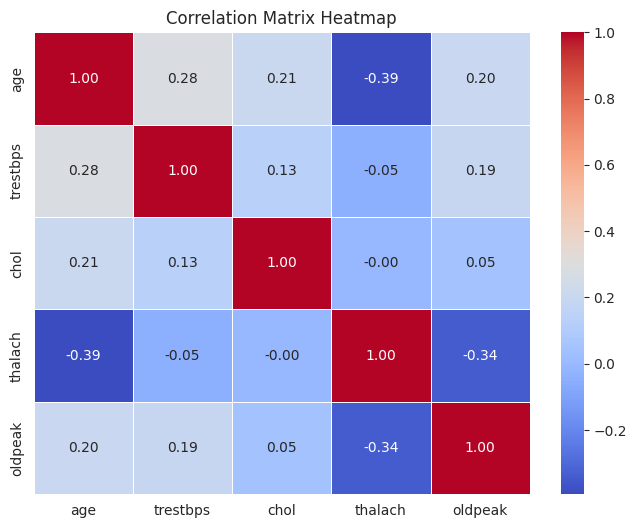

In [16]:
# check for correlation matrix

# calculating correlation matrix
corr_matrix = df_num.corr(numeric_only=True)
print(corr_matrix)  # View correlation values

# Set the background style to white
sns.set_style('white')
sns.palette='viridis'

# Create the heatmap
plt.figure(figsize=(8, 6))  # Adjust the figure size if needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

The numerical data aren't highly correlated - fit to train models.

In [17]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'log_oldpeak'],
      dtype='object')

In [18]:
df['oldpeak'] = df['log_oldpeak'].copy()
df.drop('log_oldpeak', axis=1, inplace=True)
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Now to the Machine Learning bit -

In [19]:
# we will oneHotEncode all categorical data in the main df

df_cat.columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], dtype='object')

In [20]:
col_names = df.columns
col_names

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [21]:
y = df['target']
X = df.drop('target', axis=1)

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_hot = OneHotEncoder()
transformer = ColumnTransformer([
    ('one_hot_encoding', one_hot, df_cat.columns)],
     remainder='passthrough'
)

transformed_X = transformer.fit_transform(X)
# transformed_X[:5]

In [23]:
print(transformed_X[:5])

[[  0.           1.           1.           0.           0.
    0.           0.           1.           0.           0.
    1.           1.           0.           0.           0.
    1.           1.           0.           0.           0.
    0.           0.           1.           0.           0.
   63.         145.         233.         150.           1.19392247]
 [  0.           1.           0.           0.           0.
    1.           1.           0.           0.           0.
    1.           0.           1.           0.           1.
    0.           0.           0.           0.           1.
    0.           1.           0.           0.           0.
   67.         160.         286.         108.           0.91629073]
 [  0.           1.           0.           0.           0.
    1.           1.           0.           0.           0.
    1.           0.           1.           0.           1.
    0.           0.           0.           1.           0.
    0.           0.           0.      

In [24]:
# get column names
encoded_cat_cols = transformer.named_transformers_['one_hot_encoding'].get_feature_names_out(df_cat.columns)
num_cols = [col for col in X.columns if col not in df_cat.columns]
all_cols = list(encoded_cat_cols) + num_cols

# wrap in DataFrame
X_t = pd.DataFrame(transformed_X, columns=all_cols)

In [25]:
X_t.head()

,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,...,ca_nan,thal_3.0,thal_6.0,thal_7.0,thal_nan,age,trestbps,chol,thalach,oldpeak
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,63.0,145.0,233.0,150.0,1.193922
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,67.0,160.0,286.0,108.0,0.916291
2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,67.0,120.0,229.0,129.0,1.280934
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,37.0,130.0,250.0,187.0,1.504077
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,41.0,130.0,204.0,172.0,0.875469


In [26]:
print(X_t.columns)

Index(['sex_0.0', 'sex_1.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0',
       'fbs_1.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0',
       'exang_1.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0',
       'ca_2.0', 'ca_3.0', 'ca_nan', 'thal_3.0', 'thal_6.0', 'thal_7.0',
       'thal_nan', 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
      dtype='object')


## Scoring multiple models at once using cross validation scoring

In [27]:
# using cross validation for quicker testing of accuracy of different models

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

models = {
    'RandomForest': RandomForestClassifier(n_jobs=5),
    'LinearSVC': LinearSVC(),
    'GradientBoostingClaf': HistGradientBoostingClassifier(),
    'LogisticRegression': LogisticRegression(random_state=5, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
}


for name, model in models.items():
    scores = cross_val_score(estimator=model, X=X_t, y=y, scoring='accuracy', cv=5, n_jobs=5)
    print(f"{name} -> Mean accuracy: {np.mean(scores):.4f}")

RandomForest -> Mean accuracy: 0.5971
LinearSVC -> Mean accuracy: 0.6039
GradientBoostingClaf -> Mean accuracy: 0.5807
LogisticRegression -> Mean accuracy: 0.6170
KNN -> Mean accuracy: 0.5116


## Hyperparameter Tuning with GridSearchCV

We will use `GridSearchCV` to find the best hyperparameters for `RandomForestClassifier`.

In [28]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=5, n_jobs=-1),
                            param_grid=rf_param_grid,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1)

# Fit GridSearchCV
rf_grid_search.fit(X_t, y)

# Print best parameters and best score
print(f"Best parameters for RandomForest: {rf_grid_search.best_params_}")
print(f"Best accuracy for RandomForest: {rf_grid_search.best_score_:.4f}")

Best parameters for RandomForest: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best accuracy for RandomForest: 0.6136


Next, let's tune `LogisticRegression`.

In [29]:
# Define the parameter grid for LogisticRegression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Initialize GridSearchCV
lr_grid_search = GridSearchCV(estimator=LogisticRegression(random_state=5, max_iter=1000, n_jobs=-1),
                            param_grid=lr_param_grid,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1)

# Fit GridSearchCV
lr_grid_search.fit(X_t, y)

# Print best parameters and best score
print(f"Best parameters for Logistic Regression: {lr_grid_search.best_params_}")
print(f"Best accuracy for Logistic Regression: {lr_grid_search.best_score_:.4f}")

Best parameters for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Best accuracy for Logistic Regression: 0.6104


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Tuning `LinearSVC`.

In [33]:
# Define the parameter grid for LinearSVC
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 500, 1000, 2000, 5000]
}

# Initialize GridSearchCV
lr_grid_search = GridSearchCV(estimator=LinearSVC(random_state=5),
                            param_grid=lr_param_grid,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1)

# Fit GridSearchCV
lr_grid_search.fit(X_t, y)

# Print best parameters and best score
print(f"Best parameters for LinearSVC: {lr_grid_search.best_params_}")
print(f"Best accuracy for LinearSVC: {lr_grid_search.best_score_:.4f}")

Best parameters for LinearSVC: {'C': 1, 'max_iter': 100, 'penalty': 'l1'}
Best accuracy for LinearSVC: 0.6104


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Tuning `KNN`.

In [37]:
# Define the parameter grid for LogisticRegression
lr_param_grid = {
    'n_neighbors': [40, 50, 70, 100],

}

# Initialize GridSearchCV
lr_grid_search = GridSearchCV(estimator=KNeighborsClassifier(),
                            param_grid=lr_param_grid,
                            scoring='accuracy',
                            n_jobs=-1)

# Fit GridSearchCV
lr_grid_search.fit(X_t, y)

# Print best parameters and best score
print(f"Best parameters for KNN Classifier: {lr_grid_search.best_params_}")
print(f"Best accuracy for KNN Classifier: {lr_grid_search.best_score_:.4f}")

Best parameters for KNN Classifier: {'n_neighbors': 50}
Best accuracy for KNN Classifier: 0.5445


## Conclusion:
We observe that the tree based models are very well fit to be used w
ith this dataset, with having accuracy of more than 99%. Linear models follow next with roughly 86% accuracy. This can be further improved with much more transformations. In contrast, K-Nearest Neighbors (KNN) lags behind, reaching only 72% accuracy, suggesting it may not be the optimal choice for this problem.

## Final Conclusion

After applying One-Hot Encoding to categorical features and conducting hyperparameter tuning using `GridSearchCV` on several models, we observed varying levels of performance. The best performing models and their respective accuracies after tuning were:

- **RandomForestClassifier**: Achieved an accuracy of `0.6136` with parameters `{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}`.
- **LogisticRegression**: Achieved an accuracy of `0.6104` with parameters `{'C': 1, 'solver': 'liblinear'}`.
- **LinearSVC**: Achieved an accuracy of `0.6104` with parameters `{'C': 1, 'max_iter': 100, 'penalty': 'l1'}`.
- **KNeighborsClassifier**: Achieved an accuracy of `0.5445` with parameter `{'n_neighbors': 50}`.

While hyperparameter tuning slightly improved the accuracy for some models, the overall predictive performance remains moderate. Further improvements could potentially be achieved through more advanced feature engineering, exploring different imputation strategies for missing values, or trying more complex ensemble methods. The presence of a warning about `Liblinear` failing to converge for `LinearSVC` also indicates potential for further optimization of `max_iter` or alternative solvers, particularly given the relatively high number of features after one-hot encoding.